# Initial configuration

In [1]:
import os
import torch
from pathlib import Path
from matplotlib import font_manager
import matplotlib.pyplot as plt
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

# Data Paths 
DATASET_PATH = '../DATA/chinese-handwriting'          # ETL9G Dataset (_unpack folders)

# Output Paths
OUTPUT_DIR = './HSK_Training_Output'                     # Main output folder

# File Names
MODEL_FILENAME = 'best_model.pth'              # Trained model
HISTORY_FILENAME = 'training_history.json'           # Training history
CLASSES_FILENAME = 'classes.json'                    # Class mapping

# Full File Paths 
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, MODEL_FILENAME)
HISTORY_SAVE_PATH = os.path.join(OUTPUT_DIR, HISTORY_FILENAME)
CLASSES_SAVE_PATH = os.path.join(OUTPUT_DIR, CLASSES_FILENAME)
MODEL_PATH = MODEL_SAVE_PATH  # Alias for prediction scripts

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Fonts 
FONT_PATH = "../Noto_Sans_JP/static/NotoSansJP-Regular.ttf"

def load_font():
    font_path = Path(FONT_PATH)

    if font_path.exists():
        font_manager.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
        print("Font loaded.")
    else:
        print(f"WARNING: Font not found at {font_path}.")

# Hyperparameters
BATCH_SIZE = 128         
LEARNING_RATE = 0.002
NUM_EPOCHS = 30
IMG_SIZE = 128

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Paths configuration loaded")
print(f"   • Dataset: {DATASET_PATH}")
print(f"   • Output: {OUTPUT_DIR}")
print(f"   • Model: {MODEL_SAVE_PATH}")

Using device: cuda
Paths configuration loaded
   • Dataset: ../DATA/chinese-handwriting
   • Output: ./HSK_Training_Output
   • Model: ./HSK_Training_Output/best_model.pth


# Dataset and model setup

In [2]:
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from PIL import Image
import torch.optim as optim
from tqdm import tqdm 

# Helper classes for custom data augmentation
class RandomInvert(object):
    # Randomly inverts image colors (white to black)
    def __call__(self, img):
        if torch.rand(1) < 0.5:
            return transforms.functional.invert(img)
        return img
    
class AddGaussianNoise(object):
    # Adds random noise to the image to improve model robustness
    def __init__(self, mean=0., std=0.05):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

# Data Augmentation and Transforms
train_transforms = transforms.Compose([ 
    transforms.Resize((IMG_SIZE, IMG_SIZE)), 
    transforms.Grayscale(num_output_channels=3), # ResNet requires 3 channels
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3), 
    transforms.RandomAffine( 
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1),
        shear=5
    ),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),   
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)), 
    RandomInvert(), 
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.03), 
    transforms.RandomErasing(p=0.3), 
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([ 
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load and Index Dataset
print("Loading datasets from folders...")

# Define explicit paths for Train and Test folders in the new dataset
TRAIN_DIR = os.path.join(DATASET_PATH, 'CASIA-HWDB_Train', 'Train')
TEST_DIR = os.path.join(DATASET_PATH, 'CASIA-HWDB_Test', 'Test')

# Load the Train folder twice: once with augmentation (for train) and once clean (for validation)
full_train_dataset_aug = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
full_train_dataset_clean = datasets.ImageFolder(root=TRAIN_DIR, transform=val_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=val_transforms)

# Split the original Train folder into Train (90%) and Validation (10%)
total_train_imgs = len(full_train_dataset_aug)
train_size = int(0.9 * total_train_imgs)
val_size = total_train_imgs - train_size

print(f"Splitting Train folder: Train={train_size}, Val={val_size}")

# Create random indices for splitting
generator = torch.Generator().manual_seed(42)
train_dataset_split, val_dataset_split = random_split(
    range(total_train_imgs), [train_size, val_size], generator=generator
)

# Map indices to the correct dataset versions
train_subset = Subset(full_train_dataset_aug, train_dataset_split.indices)
val_subset = Subset(full_train_dataset_clean, val_dataset_split.indices)

# Initialize DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("DataLoaders ready")

# Model Setup
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
input_features = model.fc.in_features 
num_classes = len(full_train_dataset_aug.classes) 

model.fc = nn.Linear(input_features, num_classes) # Adapting last layer
model = model.to(device)
print(f"{type(model).__name__} configured for {num_classes} classes.")

Loading datasets from folders...
Splitting Train folder: Train=95877, Val=10654
DataLoaders ready
ResNet configured for 178 classes.


# Model training

In [3]:
import json

# Main training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    best_acc = 0.0
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    print(f"Saving results to: {OUTPUT_DIR}")
    
    for epoch in range(num_epochs): 
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Training Phase
        model.train() # Set model to training mode (enables Dropout/BatchNorm)
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() # Clear gradients from previous step
            
            # Forward pass: Compute predicted outputs by passing inputs to the model
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
        
            loss = criterion(outputs, labels) # Calculate loss
        
            loss.backward() # Compute gradients
            
            optimizer.step() # Updates network weights based on gradients

            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # Training stats
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double().item() / len(train_loader.dataset)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Validation
        model.eval() # Set model to evaluation mode 
        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        # Validation stats
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_corrects.double().item() / len(val_loader.dataset)
        
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_SAVE_PATH) 
            print(f"Model saved: {MODEL_SAVE_PATH}")

    print('\nTraining finished.')
    return model, history

# Execution 
criterion = nn.CrossEntropyLoss() # Loss function
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)  
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS)

# Save history and classes
with open(HISTORY_SAVE_PATH, 'w') as f:
    json.dump(history, f)
print(f"History saved to: {HISTORY_SAVE_PATH}")

with open(CLASSES_SAVE_PATH, 'w') as f:
    json.dump(full_train_dataset_clean.classes, f, ensure_ascii=False)  
print(f"Classes saved to: {CLASSES_SAVE_PATH}")

Saving results to: ./HSK_Training_Output

Epoch 1/30
----------


Training: 100%|██████████| 750/750 [03:40<00:00,  3.41it/s]

Train Loss: 1.0347 Acc: 0.7321


Val Loss: 0.2694 Acc: 0.9198
Model saved: ./HSK_Training_Output/best_model.pth

Epoch 2/30
----------


Training: 100%|██████████| 750/750 [03:16<00:00,  3.82it/s]

...

Train Loss: 0.1129 Acc: 0.9654


Val Loss: 0.0719 Acc: 0.9829

Epoch 30/30
----------


Training: 100%|██████████| 750/750 [03:06<00:00,  4.01it/s]

Train Loss: 0.1083 Acc: 0.9666


Val Loss: 0.0645 Acc: 0.9850
Model saved: ./HSK_Training_Output/best_model.pth

Training finished.
History saved to: ./HSK_Training_Output/training_history.json
Classes saved to: ./HSK_Training_Output/classes.json


# Training metrics

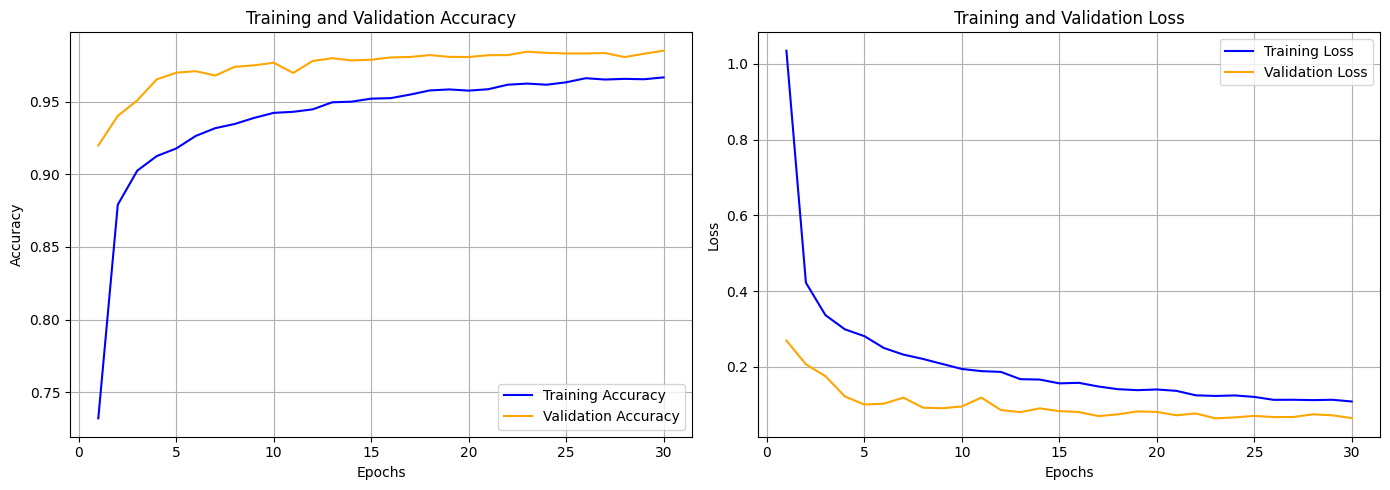

In [4]:
import json
import matplotlib.pyplot as plt

def plot_training_history():
    with open(HISTORY_SAVE_PATH, 'r') as f:
        history = json.load(f)
    
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(1, len(acc) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)
    
    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
plot_training_history()

# Test evaluation

Font loaded.
Classes loaded from ./HSK_Training_Output/classes.json (178 classes).
Analyzing Test data...


Processing: 100%|██████████| 199/199 [00:18<00:00, 11.05it/s]


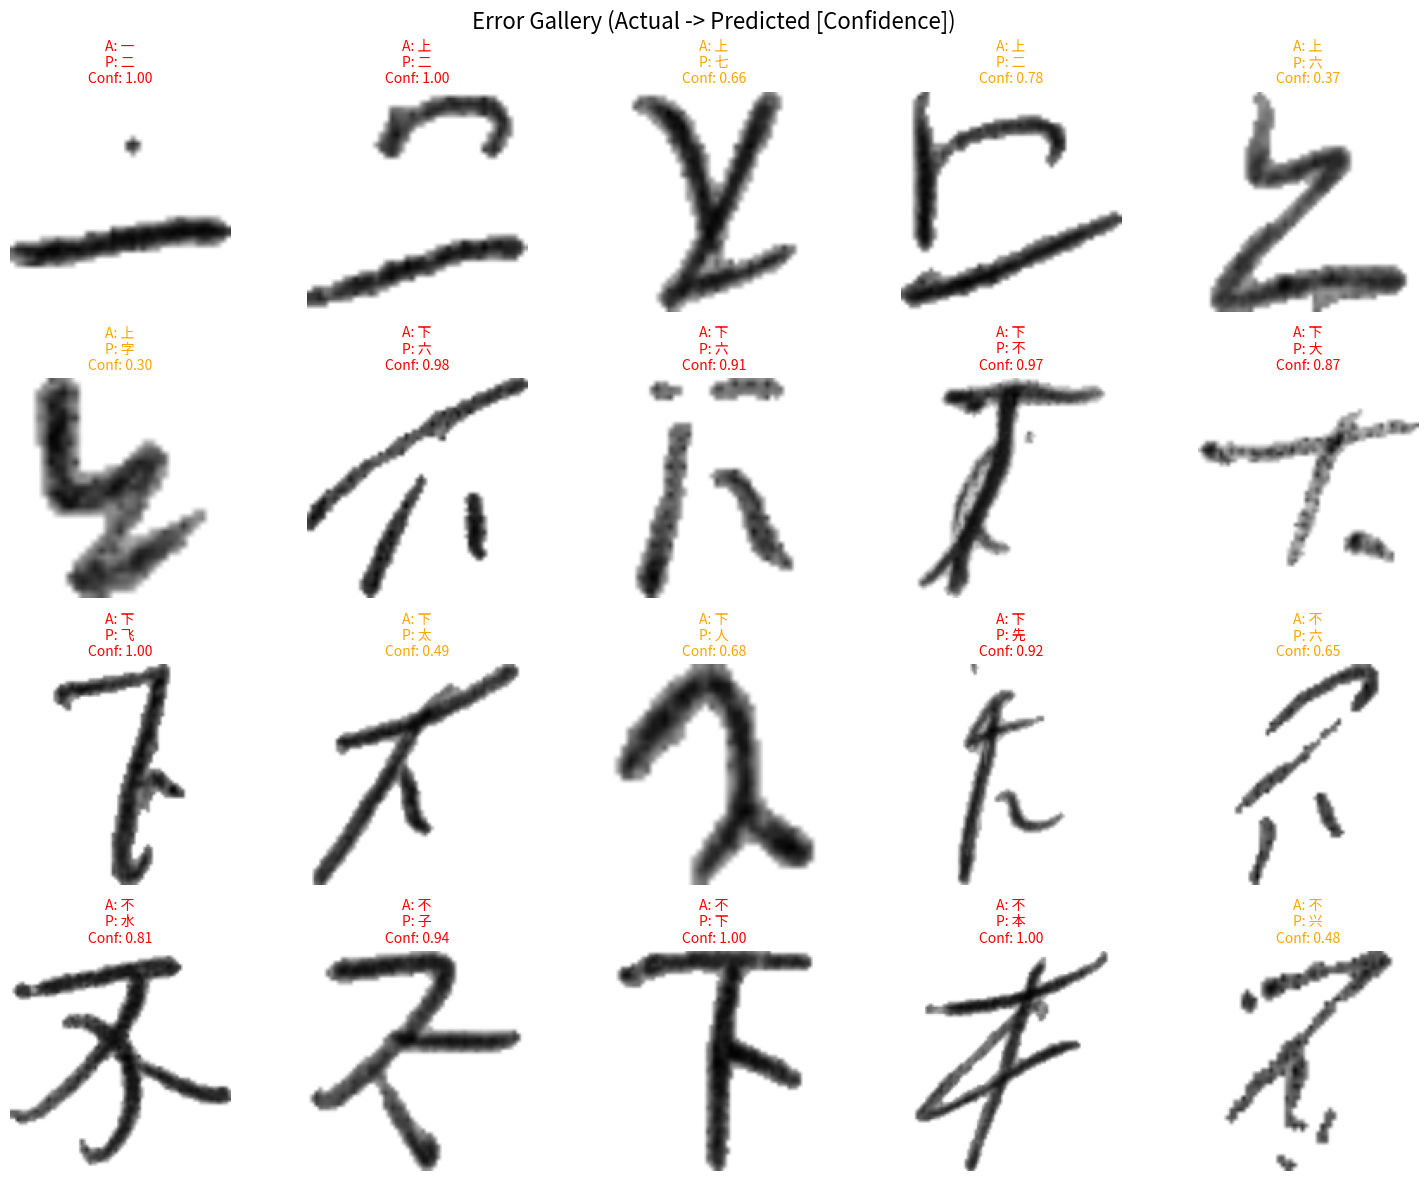


--- TOP KANJIS WITH MOST ERRORS ---
Actual
四    22
生    20
几    16
儿    15
日    15
月    12
八    11
明    11
六     9
小     9
Name: count, dtype: int64

--- MOST COMMON CONFUSIONS (Actual -> Predicted) ---
Actual  Predicted
四       回            16
生       坐            11
八       人            11
日       月            10
儿       几            10
几       儿             8
月       同             7
几       九             6
东       车             5
明       朋             5
dtype: int64

Global Test Accuracy: 97.82%


In [5]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch
from tqdm import tqdm
import json

# Loading a displayable japanese font
load_font()

# Function to display some tests
def visualize_errors_and_metrics(model, test_loader, class_names):
    model.eval() # Set model to evaluation mode
    all_preds = []
    all_labels = []
    mistakes = [] 
    MISTAKES_TO_DISPLAY = 20
    ROWS = 4
    COLUMNS = 5
    
    print("Analyzing Test data...")
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Processing"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            conf, preds = torch.max(probs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            wrong_indices = (preds != labels).nonzero()
            for idx in wrong_indices:
                idx = idx.item()
                if len(mistakes) < MISTAKES_TO_DISPLAY: # Just displaying limited mistakes
                    img = inputs[idx].cpu()
                    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                    img = img * std + mean
                    img = torch.clamp(img, 0, 1)
                    
                    mistakes.append({
                        'img': img,
                        'pred_lbl': class_names[preds[idx].item()],
                        'true_lbl': class_names[labels[idx].item()],
                        'conf': conf[idx].item()
                    })

    # Displaying mistakes
    if len(mistakes) > 0:
        fig, axes = plt.subplots(ROWS, COLUMNS, figsize=(15, 12))
        fig.suptitle('Error Gallery (Actual -> Predicted [Confidence])', fontsize=16)
        axes = axes.flatten()
        
        for i, ax in enumerate(axes):
            if i < len(mistakes):
                m = mistakes[i]
                img_np = m['img'].permute(1, 2, 0).numpy()
                ax.imshow(img_np)
                
                color = 'red' if m['conf'] > 0.8 else 'orange'
                ax.set_title(f"A: {m['true_lbl']}\nP: {m['pred_lbl']}\nConf: {m['conf']:.2f}", 
                             color=color, fontsize=10, fontweight='bold')
            ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("No errors found in the visualized sample.")

    # Stats
    df = pd.DataFrame({
        'Actual': [class_names[i] for i in all_labels],
        'Predicted': [class_names[i] for i in all_preds]
    })
    
    errors_df = df[df['Actual'] != df['Predicted']]
    
    if not errors_df.empty:
        print("\n--- TOP KANJIS WITH MOST ERRORS ---")
        print(errors_df['Actual'].value_counts().head(10))
        
        print("\n--- MOST COMMON CONFUSIONS (Actual -> Predicted) ---")
        print(errors_df.groupby(['Actual', 'Predicted']).size().sort_values(ascending=False).head(10))
    
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\nGlobal Test Accuracy: {acc*100:.2f}%")

# Execution
try:
    with open(CLASSES_SAVE_PATH, 'r') as f:
        class_names = json.load(f)
    print(f"Classes loaded from {CLASSES_SAVE_PATH} ({len(class_names)} classes).")
except FileNotFoundError:
    print(f"File not found {CLASSES_SAVE_PATH}. Using global variable 'full_train_dataset_clean'...")
    class_names = full_train_dataset_clean.classes

model = model.to(device)
visualize_errors_and_metrics(model, test_loader, class_names)